# Análise Exploratória — Home Credit Default Risk
**Projeto Final · MBA Big Data & Analytics (FIA/LABDATA) — Ponto ii (CRISP-DM: Data Understanding)**

Objetivo: entender a **qualidade da base**, **valores nulos**, **inconsistências** e o **comportamento das variáveis** em relação ao alvo (`TARGET`), preparando a decisão da ABT (Ponto iii).

> Como rodar no VS Code: abra esta pasta, selecione o kernel Python e execute célula a célula (Shift+Enter).
> Dependências: `pandas`, `numpy`, `matplotlib`.

## 0. Instalar dependências (rode apenas se der `ModuleNotFoundError`)
Instala as bibliotecas no ambiente/kernel **selecionado** no VS Code. Rode uma vez e, em seguida, **reinicie o kernel** (Restart) antes de continuar.

In [2]:
# Rode esta celula UMA vez se faltar alguma biblioteca (ex.: "No module named 'pandas'").
# Depois clique em "Restart" no kernel e siga a partir da secao 1.
%pip install pandas numpy matplotlib

  Using cached pandas-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached pandas-3.0.3-cp314-cp314-macosx_11_0_arm64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 36.2 MB/s  0:00:00 36.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 48.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]37m━━━━ 8/9 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


## 1. Setup e configuração do caminho da base

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Paleta do projeto
AZUL, VERM, TEAL = "#0F2C4C", "#C0392B", "#1C7293"

# >>> Se necessário, ajuste DATA_PATH para o caminho do application_train.csv na sua máquina <<<
CANDIDATOS = [
    Path("../home-credit-default-risk/application_train.csv"),
    Path("../home-credit-default-risk/application_train.csv"),
    Path(r"/home-credit-default-risk/application_train.csv"),
]
DATA_PATH = next((p for p in CANDIDATOS if p.exists()), None)
assert DATA_PATH is not None, "Ajuste DATA_PATH: nao encontrei application_train.csv"
print("Lendo:", DATA_PATH)

Lendo: home-credit-default-risk/application_train.csv


## 2. Carga e visão geral da base

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Linhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum()/1e6:,.1f} MB")
df.head()

Linhas: 307,511  |  Colunas: 122
Memoria: 529.5 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0

In [3]:
print("Tipos de coluna:")
print(df.dtypes.value_counts())
print("\nColunas numericas:", df.select_dtypes(include=[np.number]).shape[1])
print("Colunas categoricas (object):", df.select_dtypes(include="object").shape[1])

Tipos de coluna:
float64    65
int64      41
str        16
Name: count, dtype: int64

Colunas numericas: 106
Colunas categoricas (object): 16


## 3. Variável-alvo (`TARGET`) — desbalanceamento
`TARGET = 1` → cliente com dificuldade de pagamento (inadimplente). `0` → pagou em dia.

TARGET
0    282686
1     24825
Name: count, dtype: int64

Taxa de inadimplencia (TARGET=1): 8.07%
Proporcao bom:mau = 11.4 : 1  (base desbalanceada)


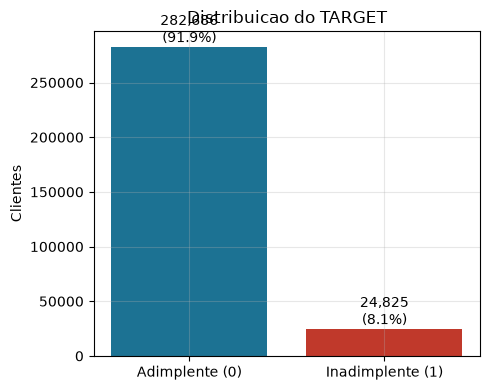

In [4]:
tgt = df["TARGET"].value_counts().sort_index()
taxa = df["TARGET"].mean()
print(tgt)
print(f"\nTaxa de inadimplencia (TARGET=1): {taxa:.2%}")
print(f"Proporcao bom:mau = {tgt[0]/tgt[1]:.1f} : 1  (base desbalanceada)")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(["Adimplente (0)", "Inadimplente (1)"], tgt.values, color=[TEAL, VERM])
for i, v in enumerate(tgt.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuicao do TARGET"); ax.set_ylabel("Clientes")
plt.tight_layout(); plt.show()

## 4. Qualidade da base — valores nulos

In [5]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(1)
tab_nulos = pd.DataFrame({"qtd_nulos": nulos, "pct_nulos_%": pct})
print(f"Colunas com algum nulo: {len(tab_nulos)} de {df.shape[1]}")
print(f"Colunas com >50% de nulos: {(pct>50).sum()}")
tab_nulos.head(20)

Colunas com algum nulo: 67 de 122
Colunas com >50% de nulos: 41


,qtd_nulos,pct_nulos_%
COMMONAREA_MEDI,214865,69.90
COMMONAREA_AVG,214865,69.90
COMMONAREA_MODE,214865,69.90
NONLIVINGAPARTMENTS_MEDI,213514,69.40
NONLIVINGAPARTMENTS_MODE,213514,69.40
NONLIVINGAPARTMENTS_AVG,213514,69.40
FONDKAPREMONT_MODE,210295,68.40
LIVINGAPARTMENTS_MODE,210199,68.40
LIVINGAPARTMENTS_MEDI,210199,68.40
LIVINGAPARTMENTS_AVG,210199,68.40


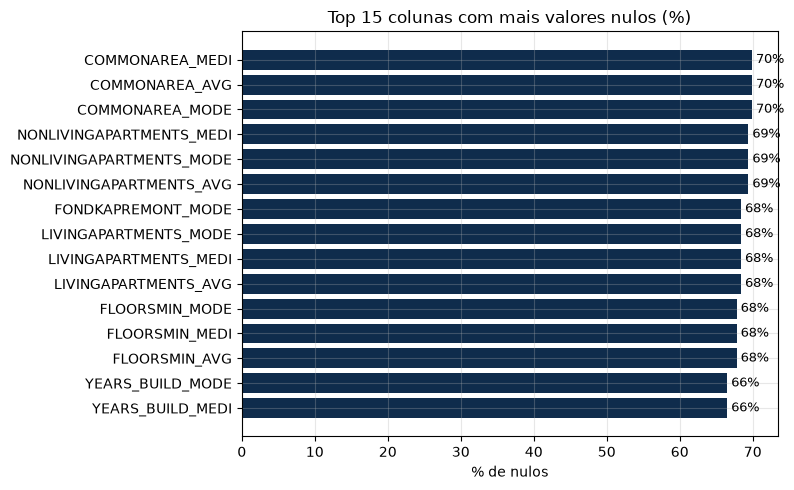

In [6]:
top = pct.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top.index, top.values, color=AZUL)
for i, v in enumerate(top.values):
    ax.text(v, i, f" {v:.0f}%", va="center", fontsize=9)
ax.set_title("Top 15 colunas com mais valores nulos (%)"); ax.set_xlabel("% de nulos")
plt.tight_layout(); plt.show()

## 5. Inconsistências e valores suspeitos

In [7]:
# 5.1 DAYS_EMPLOYED: valor sentinela 365243 (~1000 anos) = "nao se aplica"
anom = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"DAYS_EMPLOYED == 365243 (anomalo): {anom:,} registros ({anom/len(df):.1%})")
print("Esse codigo deve virar NaN antes da modelagem.\n")

# 5.2 CODE_GENDER com categoria 'XNA'
print("CODE_GENDER:")
print(df["CODE_GENDER"].value_counts())
print()

# 5.3 Variaveis em DIAS negativos (referencia = data da solicitacao)
for c in ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH"]:
    print(f"{c}: min={df[c].min():,.0f}  max={df[c].max():,.0f}")

DAYS_EMPLOYED == 365243 (anomalo): 55,374 registros (18.0%)
Esse codigo deve virar NaN antes da modelagem.

CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

DAYS_BIRTH: min=-25,229  max=-7,489
DAYS_EMPLOYED: min=-17,912  max=365,243
DAYS_REGISTRATION: min=-24,672  max=0
DAYS_ID_PUBLISH: min=-7,197  max=0


In [8]:
# Converter para unidades legiveis (df auxiliar, nao altera o original)
aux = df.copy()
aux["IDADE_ANOS"] = (-aux["DAYS_BIRTH"] / 365.25).round(1)
aux.loc[aux["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan  # corrige anomalia
aux["ANOS_EMPREGO"] = (-aux["DAYS_EMPLOYED"] / 365.25).round(1)
aux[["IDADE_ANOS", "ANOS_EMPREGO"]].describe()

,IDADE_ANOS,ANOS_EMPREGO
count,"307,511.00","252,137.00"
mean,43.91,6.53
std,11.95,6.40
min,20.50,-0.00
25%,34.00,2.10
50%,43.10,4.50
75%,53.90,8.70
max,69.10,49.00


## 6. Comportamento das variáveis numéricas vs. inadimplência

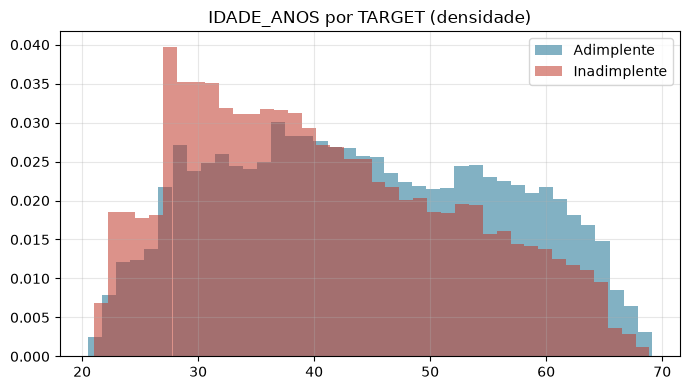

In [9]:
def hist_por_target(col, dados=None, bins=40, xlim=None):
    dados = aux if dados is None else dados
    fig, ax = plt.subplots(figsize=(7,4))
    for t, cor, lab in [(0, TEAL, "Adimplente"), (1, VERM, "Inadimplente")]:
        s = dados.loc[dados["TARGET"] == t, col].dropna()
        ax.hist(s, bins=bins, density=True, alpha=0.55, color=cor, label=lab)
    if xlim: ax.set_xlim(xlim)
    ax.set_title(f"{col} por TARGET (densidade)"); ax.legend()
    plt.tight_layout(); plt.show()

hist_por_target("IDADE_ANOS")

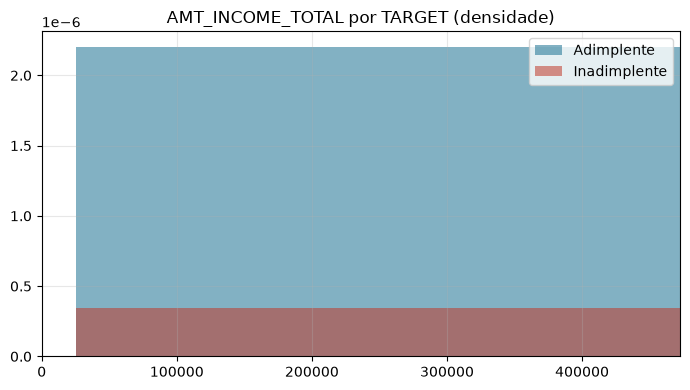

In [10]:
lim = aux["AMT_INCOME_TOTAL"].quantile(0.99)
hist_por_target("AMT_INCOME_TOTAL", xlim=(0, lim))

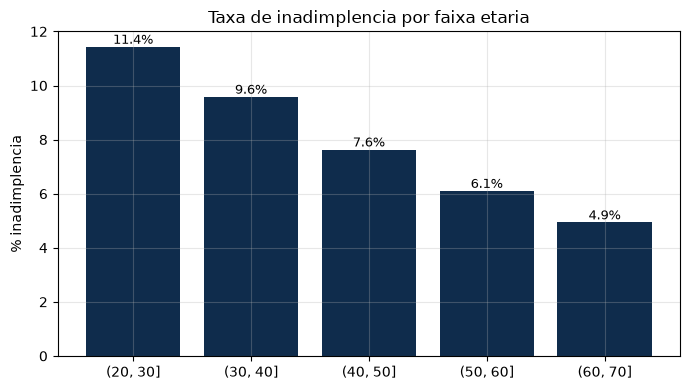

In [11]:
faixas = pd.cut(aux["IDADE_ANOS"], bins=[20,30,40,50,60,70])
taxa_idade = aux.groupby(faixas, observed=False)["TARGET"].mean()*100
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(taxa_idade.index.astype(str), taxa_idade.values, color=AZUL)
for i, v in enumerate(taxa_idade.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Taxa de inadimplencia por faixa etaria"); ax.set_ylabel("% inadimplencia")
plt.tight_layout(); plt.show()

## 7. Variáveis categóricas — taxa de inadimplência por categoria

In [12]:
def taxa_por_categoria(col, dados=None, min_n=500):
    dados = df if dados is None else dados
    g = dados.groupby(col)["TARGET"].agg(["mean", "count"])
    g = g[g["count"] >= min_n].sort_values("mean", ascending=False)
    g["mean"] = (g["mean"]*100).round(2)
    g.columns = ["taxa_inadimplencia_%", "n"]
    return g

for c in ["NAME_CONTRACT_TYPE", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE"]:
    print(f"\n=== {c} ===")
    print(taxa_por_categoria(c))


=== NAME_CONTRACT_TYPE ===
                    taxa_inadimplencia_%       n
NAME_CONTRACT_TYPE                              
Cash loans                          8.35  278232
Revolving loans                     5.48   29279

=== NAME_EDUCATION_TYPE ===
                               taxa_inadimplencia_%       n
NAME_EDUCATION_TYPE                                        
Lower secondary                               10.93    3816
Secondary / secondary special                  8.94  218391
Incomplete higher                              8.48   10277
Higher education                               5.36   74863

=== NAME_INCOME_TYPE ===
                      taxa_inadimplencia_%       n
NAME_INCOME_TYPE                                  
Working                               9.59  158774
Commercial associate                  7.48   71617
State servant                         5.75   21703
Pensioner                             5.39   55362


## 8. Correlação das variáveis numéricas com o `TARGET`

In [13]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()["TARGET"].drop("TARGET").sort_values()
print("Mais negativamente correlacionadas (reduzem risco):")
print(corr.head(8))
print("\nMais positivamente correlacionadas (aumentam risco):")
print(corr.tail(8))

Mais negativamente correlacionadas (reduzem risco):
EXT_SOURCE_3      -0.18
EXT_SOURCE_2      -0.16
EXT_SOURCE_1      -0.16
DAYS_EMPLOYED     -0.04
FLOORSMAX_AVG     -0.04
FLOORSMAX_MEDI    -0.04
FLOORSMAX_MODE    -0.04
AMT_GOODS_PRICE   -0.04
Name: TARGET, dtype: float64

Mais positivamente correlacionadas (aumentam risco):
REG_CITY_NOT_LIVE_CITY        0.04
FLAG_EMP_PHONE                0.05
REG_CITY_NOT_WORK_CITY        0.05
DAYS_ID_PUBLISH               0.05
DAYS_LAST_PHONE_CHANGE        0.06
REGION_RATING_CLIENT          0.06
REGION_RATING_CLIENT_W_CITY   0.06
DAYS_BIRTH                    0.08
Name: TARGET, dtype: float64


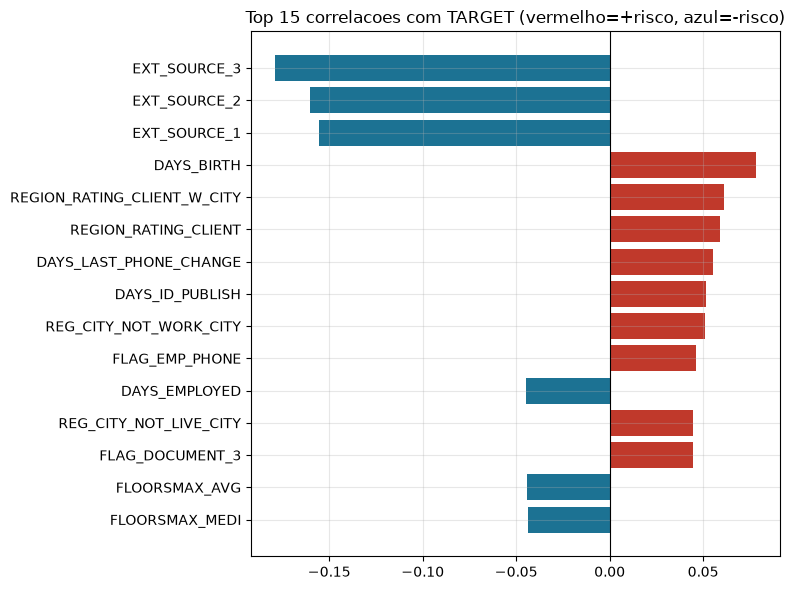

In [14]:
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15).iloc[::-1]
cores = [VERM if v > 0 else TEAL for v in top_corr.values]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top_corr.index, top_corr.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 correlacoes com TARGET (vermelho=+risco, azul=-risco)")
plt.tight_layout(); plt.show()

## 9. Resumo dos achados (Data Understanding)

- **Tamanho**: 307.511 solicitações, 122 colunas (65 float, 41 int, 16 categóricas).
- **Alvo desbalanceado**: 8,07% de inadimplência (11,4 : 1) → exige tratamento (peso de classe; métricas AUC/Recall, não acurácia).
- **Nulos**: 67 colunas com ausência, sendo 41 com >50% de nulos (bloco de variáveis de imóvel `*_AVG/_MODE/_MEDI`) → candidatas a descarte/agrupamento na ABT.
- **Inconsistências**: `DAYS_EMPLOYED == 365243` (sentinela ≈ 1000 anos) em 55.374 registros (18%) deve virar NaN; `CODE_GENDER` tem 4 registros `XNA`; `DAYS_*` são negativos (dias antes da solicitação).
- **Padrões de risco**: inadimplência cai de 11,4% (20–30 anos) para 4,9% (60–70 anos); menor `EXT_SOURCE` = maior risco; escolaridade e tipo de renda também separam grupos.
- **Preditores mais fortes**: `EXT_SOURCE_3/2/1` (correlação ≈ -0,16 a -0,18 com o risco).

➡️ **Próximo passo (Ponto iii — ABT)**: tratar a anomalia do emprego, decidir imputação/descarte de nulos, criar features (idade, razão crédito/renda) e montar a Analytical Base Table.